# Piste B — Ré-entraînement YOLO sur images en mouvement

Améliore le rappel sur vidéos en entraînant YOLO sur :
- **Source 1** : 1 000 images statiques HyperKvasir annotées par médecins
- **Source 2** : frames extraites des vidéos HyperKvasir, auto-annotées par YOLO

**Plan :** Installation → Drive → Source 1 → Source 2 → Fusion → Entraînement → Comparaison

## 1. Installation et imports

In [ ]:
!pip install ultralytics opencv-python-headless -q

import os, cv2, json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print('Imports OK')


## 2. Montage Google Drive + configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# --- Chemins a adapter selon ton Drive ---
YOLO_WEIGHTS_CURRENT = '/content/drive/MyDrive/best.pt'
VIDEO_FOLDER         = '/content/drive/MyDrive/polyps/'
STATIC_IMAGES_FOLDER = '/content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/images'
STATIC_BBOX_JSON     = '/content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/bounding-boxes.json'

# --- Parametres ---
FRAMES_PER_VIDEO = 50
CONF_THRESHOLD   = 0.25
FRAME_SKIP       = 10
EPOCHS           = 50
IMG_SIZE         = 640
WORK_DIR         = '/content/yolo_video_training'
os.makedirs(WORK_DIR, exist_ok=True)
print('Configuration OK')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuration OK


In [ ]:
import json

with open(STATIC_BBOX_JSON, "r") as f:
    data = json.load(f)

print(type(data))

if isinstance(data, dict):
    print("Nombre d'entrées :", len(data))
    print("Premières clés :", list(data.keys())[:5])

elif isinstance(data, list):
    print("Nombre d'éléments :", len(data))
    print(data[0])

<class 'dict'>
Nombre d'entrées : 1000
Premières clés : ['0dad158b-043d-427d-a656-b1034b9a6a0d', 'aa4e9e0a-de77-4c33-aa35-5fa3f6b3de41', '8b0402da-a0ef-4b97-a6d6-6ce96bdcf750', '90d30949-a733-4e0e-8fdc-b8687e8548ad', '82dea4ce-e7d5-460f-a28f-97c654ce1486']


In [ ]:
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

first_key = next(iter(bbox_all))

print("Image :", first_key)
print(bbox_all[first_key])

Image : 0dad158b-043d-427d-a656-b1034b9a6a0d
{'height': 529, 'width': 622, 'bbox': [{'label': 'polyp', 'xmin': 38, 'ymin': 5, 'xmax': 430, 'ymax': 338}]}


In [ ]:
from pprint import pprint

pprint(bbox_all[first_key])

{'bbox': [{'label': 'polyp', 'xmax': 430, 'xmin': 38, 'ymax': 338, 'ymin': 5}],
 'height': 529,
 'width': 622}


In [ ]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

print("Première clé JSON :", next(iter(bbox_all.keys())))
print("Première image :", os.listdir(STATIC_IMAGES_FOLDER)[0])

Première clé JSON : 0dad158b-043d-427d-a656-b1034b9a6a0d
Première image : 00f98835-8fd8-43fe-960d-f4a1159c30f1.jpg


## 3. Chargement du modele YOLO actuel

In [ ]:
model_current = YOLO(YOLO_WEIGHTS_CURRENT)
print('Modele YOLO actuel charge :', YOLO_WEIGHTS_CURRENT)


Modele YOLO actuel charge : /content/drive/MyDrive/best.pt


In [ ]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

image_stems = {
    os.path.splitext(f)[0]
    for f in os.listdir(STATIC_IMAGES_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

json_keys = set(bbox_all.keys())

print("Nombre d'images :", len(image_stems))
print("Nombre de clés JSON :", len(json_keys))
print("Correspondances :", len(image_stems & json_keys))

# Afficher quelques exemples d'images sans annotation
missing = list(image_stems - json_keys)
print("\nExemples d'images sans clé JSON :", missing[:10])

# Afficher quelques exemples de clés JSON sans image
extra = list(json_keys - image_stems)
print("\nExemples de clés JSON sans image :", extra[:10])

Nombre d'images : 1000
Nombre de clés JSON : 1000
Correspondances : 1000

Exemples d'images sans clé JSON : []

Exemples de clés JSON sans image : []


## 4. Source 1 — Images statiques HyperKvasir annotees

1 000 images de polypes avec vraies bounding boxes (format JSON).
On les convertit au format YOLO (coordonnees normalisees).

In [ ]:
print("STATIC_IMAGES_FOLDER =", STATIC_IMAGES_FOLDER)
print("STATIC_BBOX_JSON =", STATIC_BBOX_JSON)
print("WORK_DIR =", WORK_DIR)

STATIC_IMAGES_FOLDER = /content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/images
STATIC_BBOX_JSON = /content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/bounding-boxes.json
WORK_DIR = /content/yolo_video_training


In [ ]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

img_file = next(
    f for f in os.listdir(STATIC_IMAGES_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)

stem = os.path.splitext(img_file)[0]

print("Image :", img_file)
print("Stem :", stem)
print("Existe dans le JSON ?", stem in bbox_all)

info = bbox_all[stem]
print(info)

Image : 00f98835-8fd8-43fe-960d-f4a1159c30f1.jpg
Stem : 00f98835-8fd8-43fe-960d-f4a1159c30f1
Existe dans le JSON ? True
{'height': 530, 'width': 571, 'bbox': [{'label': 'polyp', 'xmin': 321, 'ymin': 98, 'xmax': 505, 'ymax': 400}]}


In [ ]:
import os
import json
import shutil
from PIL import Image

static_out_img = os.path.join(WORK_DIR, "source1", "images")
static_out_lbl = os.path.join(WORK_DIR, "source1", "labels")

os.makedirs(static_out_img, exist_ok=True)
os.makedirs(static_out_lbl, exist_ok=True)

# Charger le fichier unique contenant toutes les annotations
with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

static_converted = 0
static_skipped = 0

for img_file in os.listdir(STATIC_IMAGES_FOLDER):

    if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    stem = os.path.splitext(img_file)[0]

    # Vérifier que l'image possède une annotation
    if stem not in bbox_all:
        static_skipped += 1
        continue

    annotation = bbox_all[stem]

    W = annotation["width"]
    H = annotation["height"]

    boxes = annotation["bbox"]

    if len(boxes) == 0:
        static_skipped += 1
        continue

    # Copier l'image
    src_img = os.path.join(STATIC_IMAGES_FOLDER, img_file)
    dst_img = os.path.join(static_out_img, img_file)
    shutil.copy(src_img, dst_img)

    # Créer le fichier YOLO
    label_path = os.path.join(static_out_lbl, stem + ".txt")

    with open(label_path, "w") as f:

        for box in boxes:

            xmin = box["xmin"]
            ymin = box["ymin"]
            xmax = box["xmax"]
            ymax = box["ymax"]

            xc = ((xmin + xmax) / 2) / W
            yc = ((ymin + ymax) / 2) / H
            bw = (xmax - xmin) / W
            bh = (ymax - ymin) / H

            # Classe 0 = polyp
            f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

    static_converted += 1

print(f"Source 1 — Converties : {static_converted}")
print(f"Source 1 — Ignorees : {static_skipped}")

Source 1 — Converties : 1000
Source 1 — Ignorees : 0


## 5. Source 2 — Frames video + auto-annotation YOLO (pseudo-labeling)

On extrait des frames des videos HyperKvasir et on applique le modele
YOLO actuel pour generer des bounding boxes automatiques.
Seules les frames avec une detection sont conservees.

In [ ]:
video_out_img = os.path.join(WORK_DIR, 'source2', 'images')
video_out_lbl = os.path.join(WORK_DIR, 'source2', 'labels')
os.makedirs(video_out_img, exist_ok=True)
os.makedirs(video_out_lbl, exist_ok=True)

video_files = [f for f in os.listdir(VIDEO_FOLDER) if f.endswith('.avi')]
print(f'Videos trouvees : {len(video_files)}')

total_with_detection = 0

for video_file in video_files:
    vpath = os.path.join(VIDEO_FOLDER, video_file)
    vstem = os.path.splitext(video_file)[0]
    cap   = cv2.VideoCapture(vpath)
    frame_idx = 0
    extracted = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % FRAME_SKIP == 0 and extracted < FRAMES_PER_VIDEO:
            result = model_current.predict(frame, conf=CONF_THRESHOLD, verbose=False)[0]
            if len(result.boxes) > 0:
                fname = vstem + '_f' + str(frame_idx).zfill(6)
                img_path = os.path.join(video_out_img, fname + '.jpg')
                lbl_path = os.path.join(video_out_lbl, fname + '.txt')
                cv2.imwrite(img_path, frame)
                H, W = frame.shape[:2]
                lines = []
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    xc = ((x1 + x2) / 2) / W
                    yc = ((y1 + y2) / 2) / H
                    bw = (x2 - x1) / W
                    bh = (y2 - y1) / H
                    lines.append(f'0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')
                with open(lbl_path, 'w') as f:
                    f.write('\n'.join(lines))
                extracted += 1
                total_with_detection += 1
        frame_idx += 1

    cap.release()
    print(f'  {video_file}: {extracted} frames extraites')

print(f'\nSource 2 — Total frames avec detection : {total_with_detection}')


Videos trouvees : 72
  a47dce89-f633-4c51-a4e7-9506ca513839.avi: 3 frames extraites
  f9a29376-1672-4b6f-97c7-8ed490a58390.avi: 3 frames extraites
  a6340694-7315-4e1b-b8a5-c048df133d79.avi: 16 frames extraites
  76866169-90d1-42fa-ab86-0ee7bb56ea01.avi: 42 frames extraites
  89a4fc64-d698-4c09-ad17-f89257182cc2.avi: 50 frames extraites
  73bad003-9b4b-43b7-a8bf-04b6a66ecb1e.avi: 1 frames extraites
  26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi: 50 frames extraites
  8db217ce-cfd3-4aba-946d-8d2ca9f6d72e.avi: 50 frames extraites
  39de6fcf-d914-4c88-87d6-f0d11d865fd2.avi: 50 frames extraites
  8a1d3d3c-a05f-4837-9c79-de38ecb4ac2e.avi: 1 frames extraites
  7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi: 50 frames extraites
  07bf7341-7ddd-44a0-8b31-36842b8761fa.avi: 47 frames extraites
  f75949a3-bd10-4762-a7d5-1e5e42fae8e4.avi: 50 frames extraites
  5c5b3692-51a0-42fc-8836-923448e3b018.avi: 35 frames extraites
  4c0cae22-4945-4f17-a60b-23688b485d91.avi: 6 frames extraites
  5b2f37fb-8365-4b75-85c

## 6. Fusion des deux sources + split train/val

In [ ]:
import os
import random
import shutil

# ===============================
# Construction de la liste complète
# ===============================
all_samples = []
video_groups = {}

# ---------- Images statiques ----------
for fname in os.listdir(static_out_img):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    stem = os.path.splitext(fname)[0]
    lbl_path = os.path.join(static_out_lbl, stem + ".txt")

    if os.path.exists(lbl_path):
        all_samples.append(("static", os.path.join(static_out_img, fname), lbl_path))

# ---------- Images vidéo ----------
for fname in os.listdir(video_out_img):

    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    stem = os.path.splitext(fname)[0]
    lbl_path = os.path.join(video_out_lbl, stem + ".txt")

    if not os.path.exists(lbl_path):
        continue

    # Le nom de la vidéo est tout ce qui est avant "_f"
    video_name = stem.split("_f")[0]

    video_groups.setdefault(video_name, []).append(
        (os.path.join(video_out_img, fname), lbl_path)
    )

# ===============================
# Split PAR VIDEO
# ===============================

random.seed(42)

video_names = list(video_groups.keys())
random.shuffle(video_names)

n_train_video = int(0.8 * len(video_names))

train_videos = set(video_names[:n_train_video])
val_videos = set(video_names[n_train_video:])

train_samples = []
val_samples = []

# Toutes les images statiques dans le train
for sample in all_samples:
    train_samples.append(sample)

# Images vidéo
for video_name, samples in video_groups.items():

    if video_name in train_videos:
        train_samples.extend(samples)
    else:
        val_samples.extend(samples)

splits = {
    "train": train_samples,
    "val": val_samples
}

# ===============================
# Création du dataset YOLO
# ===============================

dataset_dir = os.path.join(WORK_DIR, "dataset_video")

for split, samples in splits.items():

    os.makedirs(os.path.join(dataset_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, "labels", split), exist_ok=True)

    for sample in samples:

        if len(sample) == 3:
            _, img_path, lbl_path = sample
        else:
            img_path, lbl_path = sample

        fname = os.path.basename(img_path)
        stem = os.path.splitext(fname)[0]

        shutil.copy(
            img_path,
            os.path.join(dataset_dir, "images", split, fname)
        )

        shutil.copy(
            lbl_path,
            os.path.join(dataset_dir, "labels", split, stem + ".txt")
        )

print("=" * 60)
print(f"Nombre de vidéos : {len(video_names)}")
print(f"Train vidéos : {len(train_videos)}")
print(f"Validation vidéos : {len(val_videos)}")
print()
print(f"Images train : {len(train_samples)}")
print(f"Images validation : {len(val_samples)}")
print("=" * 60)

Nombre de vidéos : 64
Train vidéos : 51
Validation vidéos : 13

Images train : 2471
Images validation : 351


In [ ]:
yaml_path = os.path.join(WORK_DIR, 'video_training.yaml')
yaml_content = 'path: ' + dataset_dir + '\ntrain: images/train\nval: images/val\n\nnames:\n  0: polype\n'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(yaml_content)


path: /content/yolo_video_training/dataset_video
train: images/train
val: images/val

names:
  0: polype



## 7. Verification visuelle du dataset (quelques exemples)

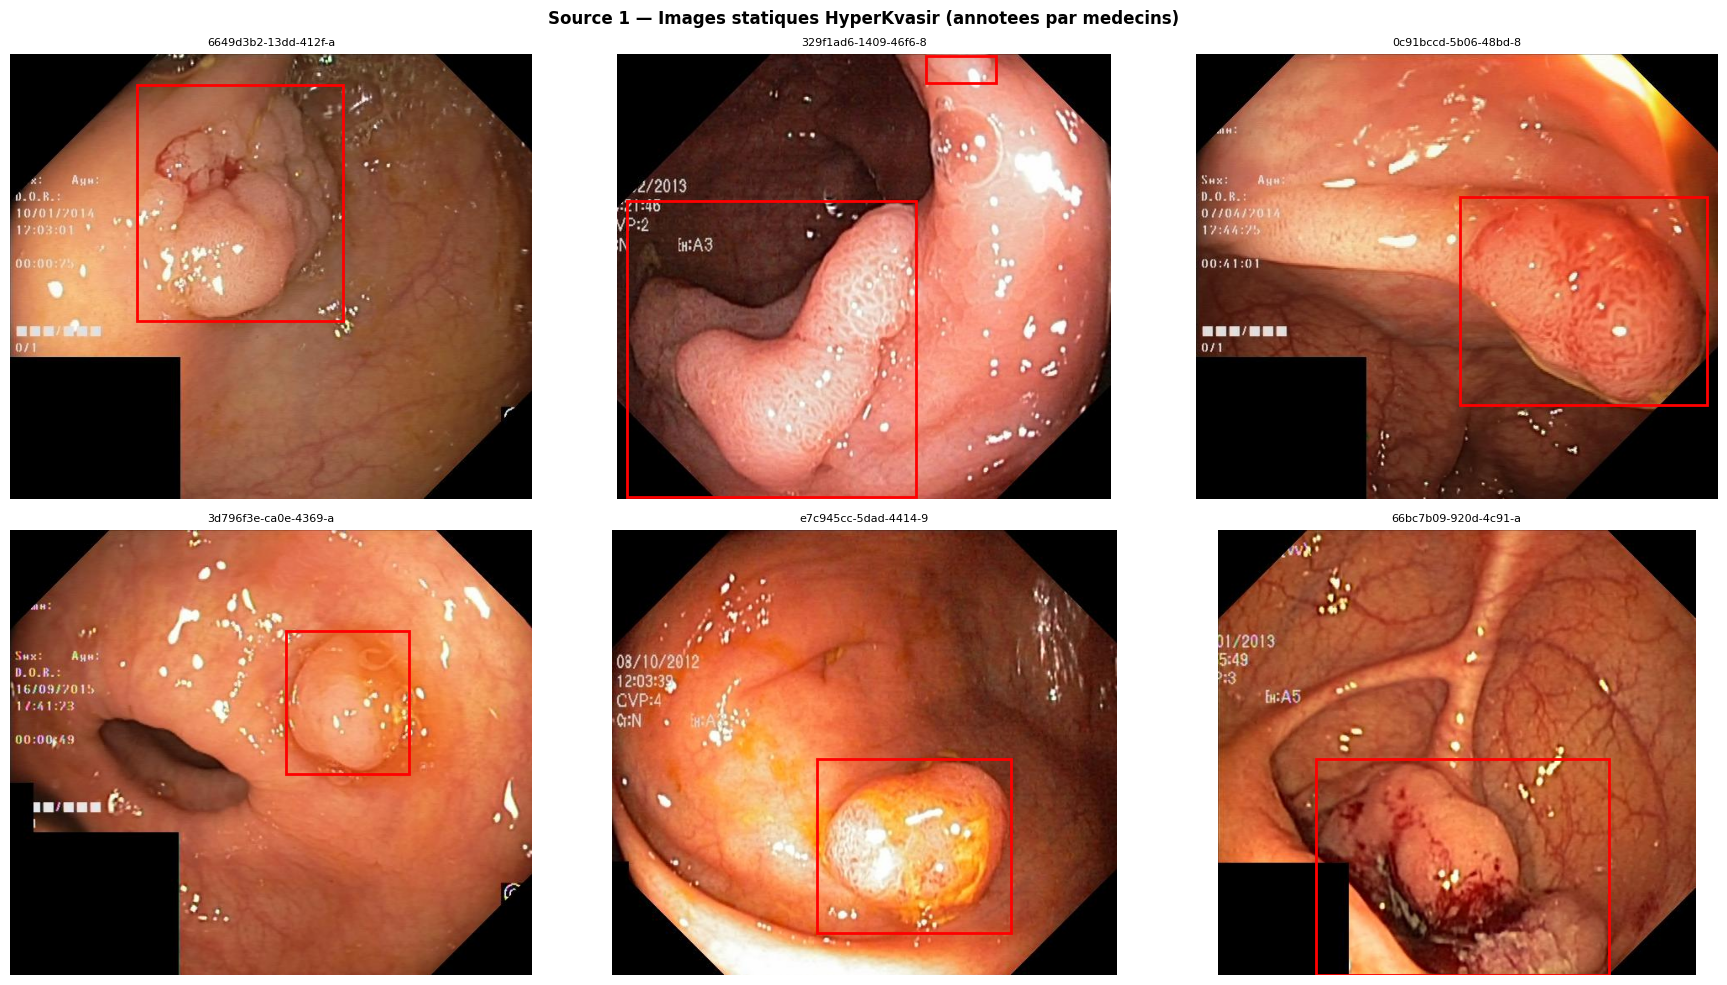

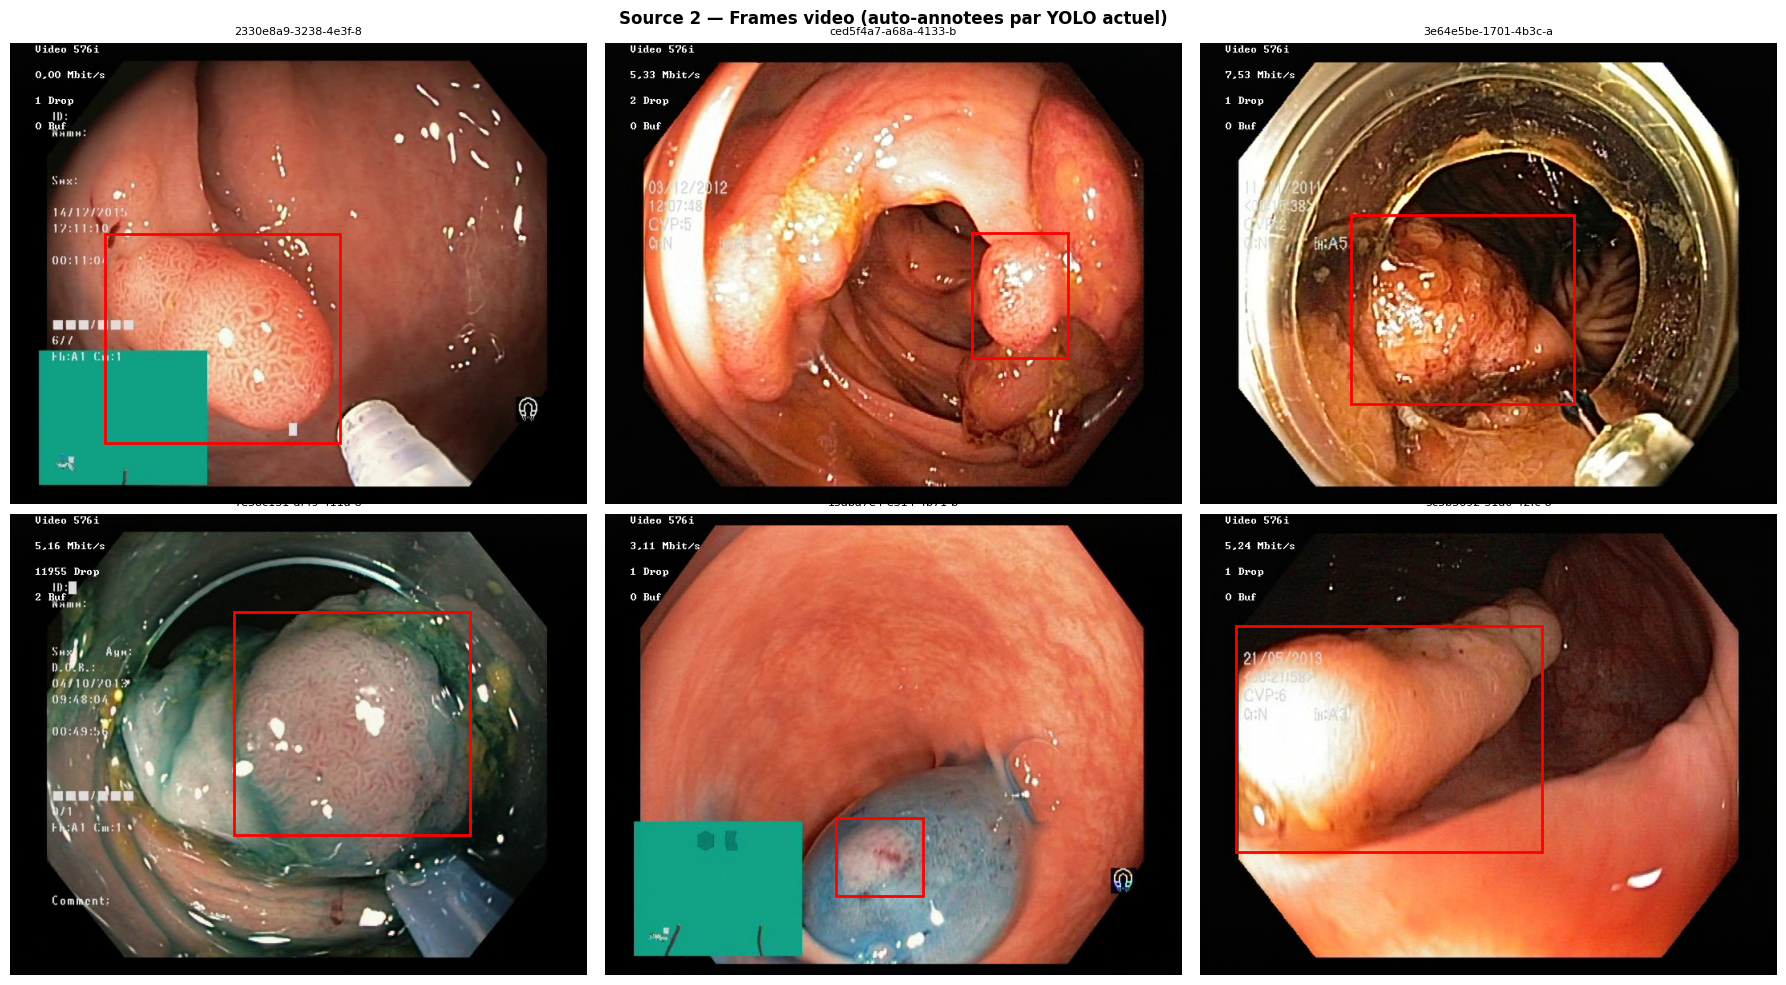

In [ ]:
def show_samples_grid(images_dir, labels_dir, title, n=6):
    files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))][:n]
    if not files:
        print('Aucune image trouvee dans', images_dir)
        return
    cols = min(3, len(files))
    rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axes = axes.flatten() if len(files) > 1 else [axes]
    for ax, fname in zip(axes, files):
        stem = os.path.splitext(fname)[0]
        img  = Image.open(os.path.join(images_dir, fname))
        W, H = img.size
        ax.imshow(img)
        lbl_path = os.path.join(labels_dir, stem + '.txt')
        if os.path.exists(lbl_path):
            for line in open(lbl_path).read().splitlines():
                if not line.strip(): continue
                _, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                ax.add_patch(patches.Rectangle((x1, y1), bw*W, bh*H,
                    linewidth=2, edgecolor='red', facecolor='none'))
        ax.set_title(fname[:20], fontsize=8)
        ax.axis('off')
    for ax in axes[len(files):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples_grid(static_out_img, static_out_lbl,
    'Source 1 — Images statiques HyperKvasir (annotees par medecins)')
show_samples_grid(video_out_img, video_out_lbl,
    'Source 2 — Frames video (auto-annotees par YOLO actuel)')


## 8. Re-entrainement YOLO sur le dataset fusionne

On part des poids actuels (`best.pt`) — le modele conserve ce qu'il
a appris et s'ameliore sur les images en mouvement (fine-tuning).

In [19]:
model_new = YOLO(YOLO_WEIGHTS_CURRENT)

results_train = model_new.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=16,

    name="yolo_polype_video",
    exist_ok=True,

    # -------------------------
    # Data Augmentation
    # -------------------------
    degrees=10.0,      # rotation
    translate=0.10,    # translation
    scale=0.50,        # zoom
    shear=2.0,         # cisaillement
    perspective=0.0,

    fliplr=0.5,        # flip horizontal
    flipud=0.0,        # éviter le retournement vertical

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.10,

    # -------------------------
    # Entraînement
    # -------------------------
    patience=20,
    cache=True,
    workers=2,
    plots=True,
    save=True,
    verbose=True,
)

new_weights_path = "runs/detect/yolo_polype_video/weights/best.pt"

print("Nouveau modele sauvegarde :", new_weights_path)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_video_training/video_training.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/content/drive/MyDrive/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_polype_video, nbs=64, nms=False, opset=No

## 9. Evaluation et comparaison avant / apres re-entrainement

In [20]:
val_images_dir = os.path.join(dataset_dir, 'images', 'val')
val_labels_dir = os.path.join(dataset_dir, 'labels', 'val')

def evaluate_on_val(model, img_dir, lbl_dir, conf=0.25):
    y_true, y_pred = [], []
    for fname in os.listdir(img_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem  = os.path.splitext(fname)[0]
        lbl   = open(os.path.join(lbl_dir, stem + '.txt')).read().strip()
        true  = 1 if lbl else 0
        pred  = model.predict(os.path.join(img_dir, fname), conf=conf, verbose=False)[0]
        y_pred.append(1 if len(pred.boxes) > 0 else 0)
        y_true.append(true)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'cm':        confusion_matrix(y_true, y_pred),
    }

print('Evaluation modele ACTUEL...')
metrics_old = evaluate_on_val(model_current, val_images_dir, val_labels_dir)

print('Evaluation NOUVEAU modele...')
model_retrained = YOLO(new_weights_path)
metrics_new = evaluate_on_val(model_retrained, val_images_dir, val_labels_dir)

print('=' * 55)
print('COMPARAISON AVANT / APRES RE-ENTRAINEMENT')
print('=' * 55)
print('{:<20} {:>10} {:>10} {:>10}'.format('Metrique', 'Avant', 'Apres', 'Delta'))
print('-' * 55)
for metric in ['accuracy', 'precision', 'recall']:
    before = metrics_old[metric]
    after  = metrics_new[metric]
    delta  = round(after - before, 4)
    sign   = '+' if delta >= 0 else ''
    print('{:<20} {:>10.4f} {:>10.4f} {:>10}'.format(
        metric.capitalize(), before, after, sign + str(delta)))
print('=' * 55)


Evaluation modele ACTUEL...
Evaluation NOUVEAU modele...
COMPARAISON AVANT / APRES RE-ENTRAINEMENT
Metrique                  Avant      Apres      Delta
-------------------------------------------------------
Accuracy                 0.9292     0.9858    +0.0566
Precision                1.0000     1.0000       +0.0
Recall                   0.9292     0.9858    +0.0566


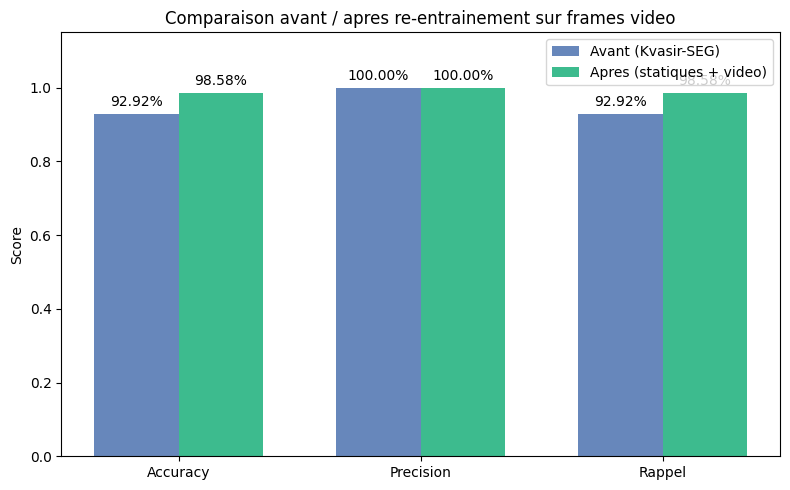

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
metric_names  = ['Accuracy', 'Precision', 'Rappel']
values_before = [metrics_old['accuracy'], metrics_old['precision'], metrics_old['recall']]
values_after  = [metrics_new['accuracy'], metrics_new['precision'], metrics_new['recall']]
x     = range(len(metric_names))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], values_before, width,
               label='Avant (Kvasir-SEG)', color='#4C72B0', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], values_after, width,
               label='Apres (statiques + video)', color='#1baf7a', alpha=0.85)
ax.set_ylim(0, 1.15)
ax.set_xticks(list(x))
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_title('Comparaison avant / apres re-entrainement sur frames video')
ax.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                '{:.2%}'.format(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('comparaison_avant_apres.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
import os
import cv2
import shutil
import pandas as pd
from ultralytics import YOLO

# -------------------------
# Charger le meilleur modèle
# -------------------------
model = YOLO(new_weights_path)

# -------------------------
# Images à analyser
# -------------------------
SOURCE_DIR = video_out_img

# -------------------------
# Dossier de sortie
# -------------------------
LOW_CONF_DIR = os.path.join(WORK_DIR, "low_confidence_cases")
os.makedirs(LOW_CONF_DIR, exist_ok=True)

records = []

# -------------------------
# Seuils
# -------------------------
LOW_CONF = 0.30
HIGH_CONF = 0.60

image_files = sorted([
    f for f in os.listdir(SOURCE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"{len(image_files)} images à analyser")

for img_name in image_files:

    img_path = os.path.join(SOURCE_DIR, img_name)

    result = model.predict(
        img_path,
        conf=0.01,
        verbose=False
    )[0]

    if len(result.boxes) == 0:
        continue

    conf = float(result.boxes.conf.max())

    if LOW_CONF <= conf <= HIGH_CONF:

        shutil.copy(
            img_path,
            os.path.join(LOW_CONF_DIR, img_name)
        )

        records.append({
            "image": img_name,
            "confidence": round(conf,4)
        })

df = pd.DataFrame(records)

csv_path = os.path.join(
    LOW_CONF_DIR,
    "low_confidence_cases.csv"
)

df.to_csv(csv_path,index=False)

print("="*60)
print("Cas limites :",len(df))
print("Images enregistrées dans :",LOW_CONF_DIR)
print("CSV :",csv_path)
print("="*60)

df.head()

1822 images à analyser
Cas limites : 105
Images enregistrées dans : /content/yolo_video_training/low_confidence_cases
CSV : /content/yolo_video_training/low_confidence_cases/low_confidence_cases.csv


,image,confidence
0,0220d11b-ab12-4b02-93ce-5d7c205c7043_f000100.jpg,0.5620
1,07bf7341-7ddd-44a0-8b31-36842b8761fa_f000230.jpg,0.4580
2,07bf7341-7ddd-44a0-8b31-36842b8761fa_f000700.jpg,0.5850
3,07bf7341-7ddd-44a0-8b31-36842b8761fa_f001380.jpg,0.5976
4,07bf7341-7ddd-44a0-8b31-36842b8761fa_f001410.jpg,0.4849


Nombre de cas limites : 105


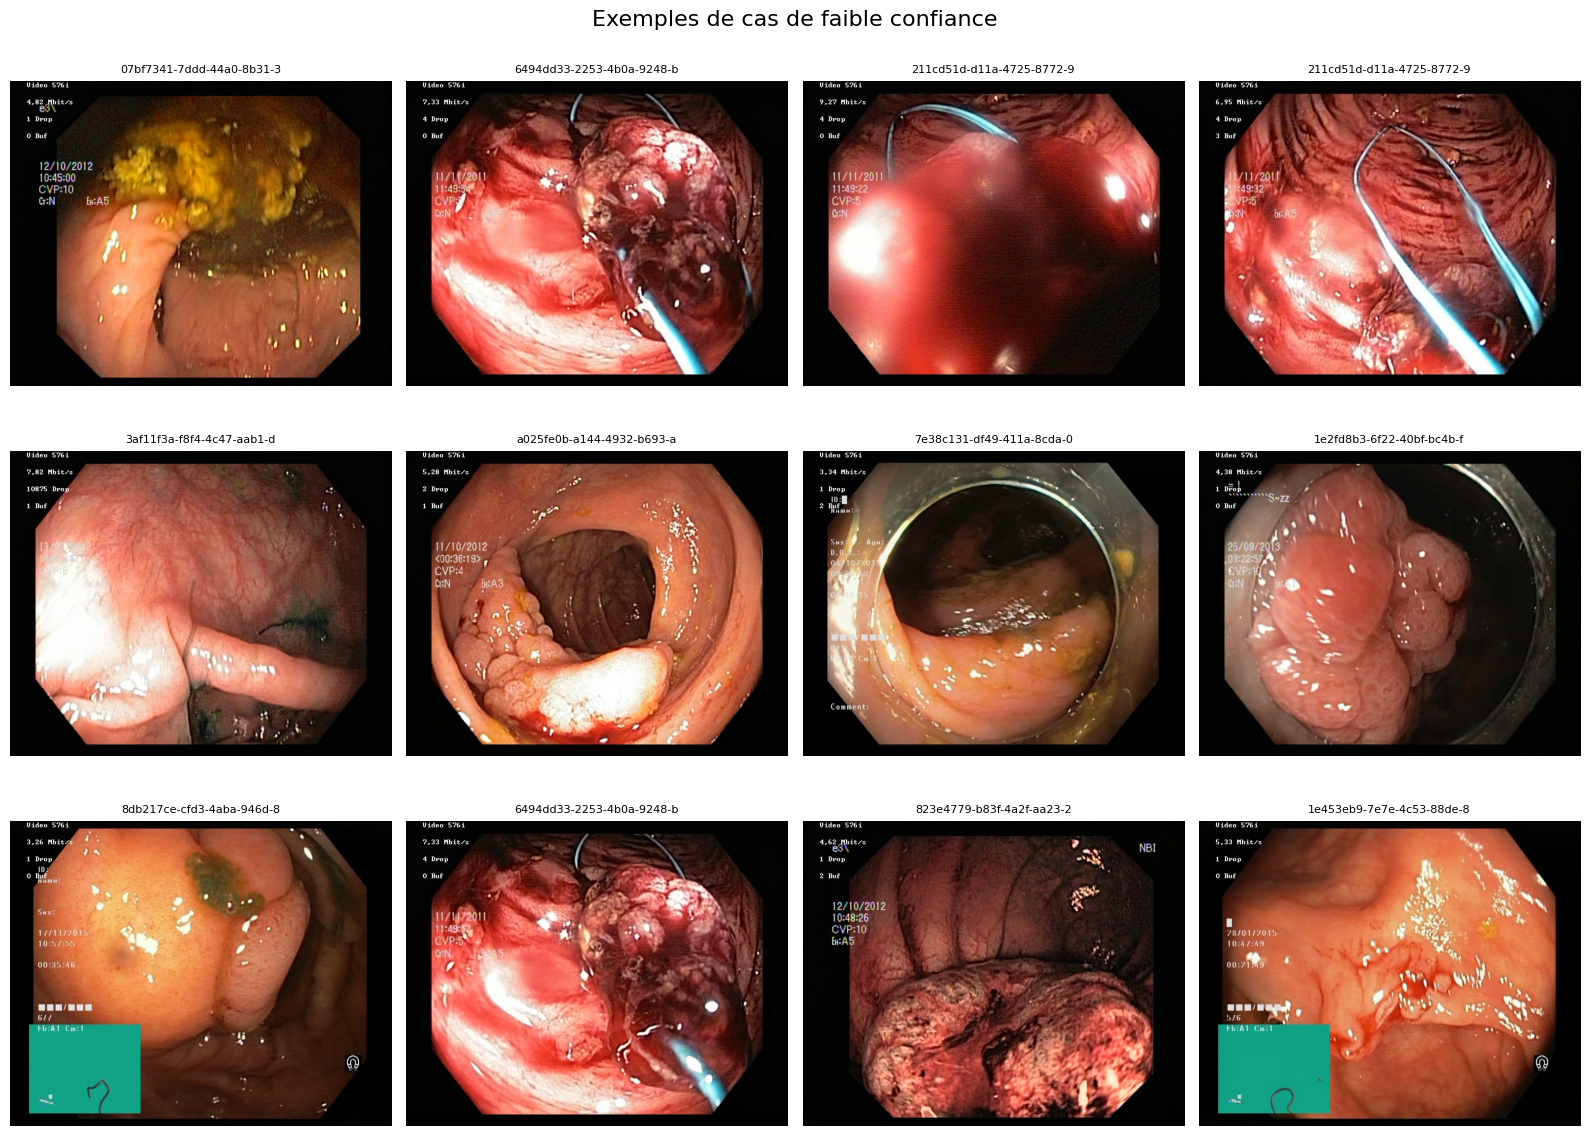

In [23]:
import os
import random
import matplotlib.pyplot as plt
import cv2

# Dossier contenant les cas limites
LOW_CONF_DIR = os.path.join(WORK_DIR, "low_confidence_cases")

images = [
    f for f in os.listdir(LOW_CONF_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Nombre de cas limites : {len(images)}")

# Afficher jusqu'à 12 images aléatoires
n = min(12, len(images))
selected = random.sample(images, n)

plt.figure(figsize=(16, 12))

for i, img_name in enumerate(selected):

    img = cv2.imread(os.path.join(LOW_CONF_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(img_name[:25], fontsize=8)
    plt.axis("off")

plt.suptitle("Exemples de cas de faible confiance", fontsize=16)
plt.tight_layout()
plt.show()

**Résumé des résultats après le réentraînement**

Le modèle YOLO a été réentraîné en intégrant des images annotées supplémentaires issues du dataset Hyper-Kvasir ainsi que des images extraites de vidéos annotées. Trois principales améliorations ont été apportées au pipeline : (1) un split par vidéo afin d'éviter les fuites d'information entre les ensembles d'entraînement et de validation, (2) l'ajout de techniques avancées d'augmentation de données pour améliorer la généralisation du modèle, et (3) la mise en place d'une étape d'Active Learning permettant d'extraire automatiquement les cas de faible confiance (105 images sur 1822 analysées) pour une future validation par un endoscopiste.

Les résultats montrent une amélioration significative des performances. L'Accuracy est passée de 92,92 % à 98,58 %, tandis que le Recall a progressé de 92,92 % à 98,58 %. La Precision est restée à 100 %, confirmant l'absence d'augmentation des faux positifs.

Dans l'ensemble, ces améliorations ont permis d'obtenir un modèle plus robuste, plus fiable et mieux généralisable, tout en préparant une stratégie d'amélioration continue grâce à l'intégration de l'expertise médicale.
| Métrique  |    Avant |    Après | Évolution |
| --------- | -------: | -------: | --------: |
| Accuracy  |  92.92 % |  98.58 % |   +5.66 % |
| Precision | 100.00 % | 100.00 % |    Stable |
| Recall    |  92.92 % |  98.58 % |   +5.66 % |
